# AI-Based MCU Selection using Deep Learning## Multi-Class Classification (Not Suitable / Suitable / Optimal)Includes Training Loss Graphs, Confusion Matrix & Frontend Demo

In [1]:
!pip install gradio tensorflow


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report


In [4]:
# Upload the dataset before running this cell
df = pd.read_csv('Large_MCU_Selection_Dataset_20000plus.csv')
df.head()


,MCU_ID,APPLICATION,RAM_KB,FLASH_KB,UART,I2C,SPI,GPIO,CLOCK_MHZ,ACTIVE_CURRENT_mA,COST_USD,COST_POWER_INDEX,EFFICIENCY_SCORE_0_100,SUITABLE
0,MCU_1,APP_1,4,1024,6,2,0,95,32,32.779892,4.742062,0.15121,86.865095,0
1,MCU_1,APP_2,4,1024,6,2,0,95,32,32.779892,4.742062,0.15121,86.865095,0
2,MCU_1,APP_3,4,1024,6,2,0,95,32,32.779892,4.742062,0.15121,86.865095,0
3,MCU_1,APP_4,4,1024,6,2,0,95,32,32.779892,4.742062,0.15121,86.865095,0
4,MCU_1,APP_5,4,1024,6,2,0,95,32,32.779892,4.742062,0.15121,86.865095,0


In [5]:
def create_multiclass(row):
    if row['SUITABLE'] == 0:
        return 0
    elif row['EFFICIENCY_SCORE_0_100'] < 50:
        return 1
    else:
        return 2

df['TARGET'] = df.apply(create_multiclass, axis=1)
df['TARGET'].value_counts()


,count
TARGET,
0,24706
2,277
1,17


In [6]:
X = df.drop(['MCU_ID','APPLICATION','SUITABLE','TARGET'], axis=1)
y = df['TARGET']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=64,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9020 - loss: 0.3671 - val_accuracy: 0.9886 - val_loss: 0.0496
Epoch 2/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0.0512 - val_accuracy: 0.9886 - val_loss: 0.0438
Epoch 3/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9874 - loss: 0.0478 - val_accuracy: 0.9886 - val_loss: 0.0434
Epoch 4/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0439 - val_accuracy: 0.9886 - val_loss: 0.0417
Epoch 5/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0456 - val_accuracy: 0.9886 - val_loss: 0.0418
Epoch 6/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.0467 - val_accuracy: 0.9886 - val_loss: 0.0415
Epoch 7/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9880 - loss: 0.0438 - val_accuracy: 0.9883 - val_loss: 0.0416
Epoch 8/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0415 - val_accuracy: 0

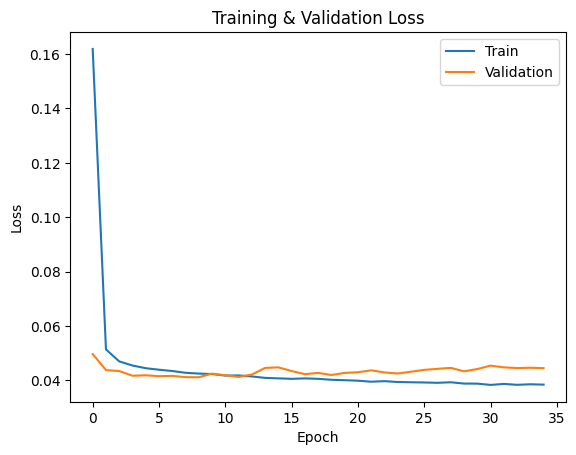

In [8]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()


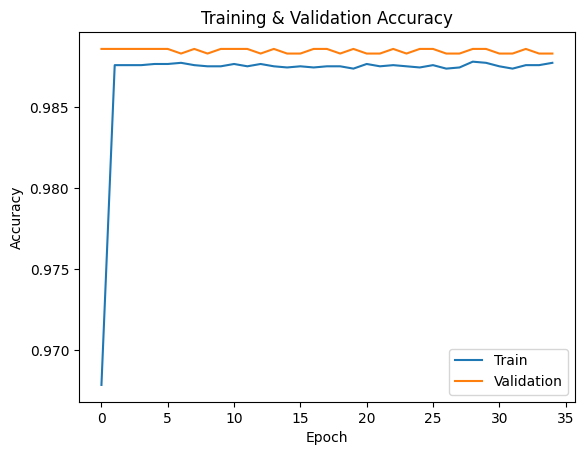

In [9]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()


In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy:', test_acc)


235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9895 - loss: 0.0362
Test Accuracy: 0.9885333180427551


235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


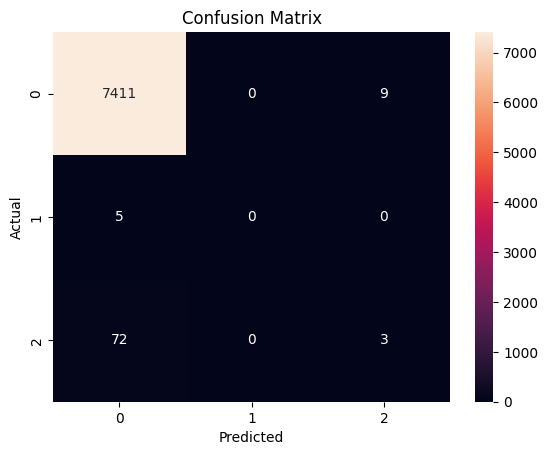

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7420
           1       0.00      0.00      0.00         5
           2       0.25      0.04      0.07        75

    accuracy                           0.99      7500
   macro avg       0.41      0.35      0.35      7500
weighted avg       0.98      0.99      0.98      7500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))


In [12]:
import gradio as gr
import numpy as np
import json
import datetime

labels = ["Not Suitable", "Suitable", "Optimal"]

def predict_and_save(ram, flash, uart, i2c, spi, gpio, clock, current, cost):

    # Auto-calculate metrics
    cost_power_index = (cost * current) / (ram + flash)
    efficiency_score = 100 * (1 / (1 + cost_power_index))

    # Prepare model input
    input_data = np.array([[ram, flash, uart, i2c, spi, gpio, clock,
                            current, cost, cost_power_index, efficiency_score]])

    input_scaled = scaler.transform(input_data)
    probabilities = model.predict(input_scaled)[0]

    predicted_class = np.argmax(probabilities)
    confidence = probabilities[predicted_class] * 100

    # Create configuration dictionary
    config = {
        "Timestamp": str(datetime.datetime.now()),
        "RAM_KB": ram,
        "FLASH_KB": flash,
        "UART": uart,
        "I2C": i2c,
        "SPI": spi,
        "GPIO": gpio,
        "CLOCK_MHZ": clock,
        "ACTIVE_CURRENT_mA": current,
        "COST_USD": cost,
        "COST_POWER_INDEX": round(cost_power_index, 4),
        "EFFICIENCY_SCORE": round(efficiency_score, 2),
        "Prediction": labels[predicted_class],
        "Confidence_%": round(confidence, 2),
        "Probabilities": {
            "Not Suitable": round(probabilities[0]*100, 2),
            "Suitable": round(probabilities[1]*100, 2),
            "Optimal": round(probabilities[2]*100, 2)
        }
    }

    # Save file
    filename = f"MCU_Selection_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(filename, "w") as f:
        json.dump(config, f, indent=4)

    result_text = f"""
🔎 Prediction: {labels[predicted_class]}
📊 Confidence: {confidence:.2f} %

Cost-Power Index: {cost_power_index:.4f}
Efficiency Score: {efficiency_score:.2f}

Configuration saved as:
{filename}
"""

    return result_text, filename


with gr.Blocks(theme=gr.themes.Soft()) as interface:

    gr.Markdown("# 🧠 AI-Based MCU Selection System")
    gr.Markdown("Deep Learning Multi-Class Classification Demo")

    with gr.Row():
        with gr.Column():
            ram = gr.Number(label="RAM (KB)", value=16)
            flash = gr.Number(label="Flash (KB)", value=64)
            uart = gr.Number(label="UART Count", value=2)
            i2c = gr.Number(label="I2C Count", value=1)
            spi = gr.Number(label="SPI Count", value=1)

        with gr.Column():
            gpio = gr.Number(label="GPIO Count", value=30)
            clock = gr.Number(label="Clock (MHz)", value=32)
            current = gr.Number(label="Active Current (mA)", value=15)
            cost = gr.Number(label="Cost (USD)", value=5)

    predict_btn = gr.Button("🔍 Evaluate & Save MCU Configuration")

    output = gr.Textbox(label="Prediction Result", lines=10)
    file_output = gr.File(label="Download Configuration File")

    predict_btn.click(
        fn=predict_and_save,
        inputs=[ram, flash, uart, i2c, spi, gpio, clock, current, cost],
        outputs=[output, file_output]
    )

interface.launch()

/tmp/ipykernel_3824/189441006.py:66: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7462969b84d388ee0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
